**Task 1 - with given code**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import tqdm
import os
import wandb

# Hyperparameters
mb_size = 64
Z_dim = 1000
h_dim = 128
lr = 1e-3

# Load MNIST data
transform = transforms.Compose([
transforms.ToTensor(),
transforms.Lambda(lambda x: x.view(-1)) # Flatten the 28x28 image to 784
])
train_dataset = datasets.MNIST(root='../MNIST', train=True, transform=transform,
download=True)
train_loader = DataLoader(train_dataset, batch_size=mb_size, shuffle=True)
X_dim = 784 # 28 x 28

# Xavier Initialization
def xavier_init(m):
  if isinstance(m, nn.Linear):
    nn.init.xavier_normal_(m.weight)
    if m.bias is not None:
      nn.init.zeros_(m.bias)

# Generator
class Generator(nn.Module):
  def __init__(self, z_dim, h_dim, x_dim):
    super(Generator, self).__init__()
    self.fc1 = nn.Linear(z_dim, h_dim)
    self.fc2 = nn.Linear(h_dim, x_dim)
    self.apply(xavier_init)
  def forward(self, z):
    h = F.relu(self.fc1(z))
    out = torch.sigmoid(self.fc2(h))
    return out

# Discriminator
class Discriminator(nn.Module):
  def __init__(self, x_dim, h_dim):
    super(Discriminator, self).__init__()
    self.fc1 = nn.Linear(x_dim, h_dim)
    self.fc2 = nn.Linear(h_dim, 1)
    self.apply(xavier_init)
  def forward(self, x):
    h = F.relu(self.fc1(x))
    out = torch.sigmoid(self.fc2(h))
    return out

# Training
def cGANTraining(G, D, loss_fn, train_loader):
    G.train()
    D.train()
    D_loss_real_total = 0
    D_loss_fake_total = 0
    G_loss_total = 0

    # tqdm creates the progress bar for the batches in one epoch
    t = tqdm.tqdm(train_loader)

    for it, (X_real, labels) in enumerate(t):
        # 1. Prepare real data and move to GPU/CPU
        X_real = X_real.float().to(device)
        batch_size = X_real.size(0)

        # 2. Define ground truth labels for this batch
        ones_label = torch.ones(batch_size, 1).to(device)
        zeros_label = torch.zeros(batch_size, 1).to(device)

        # ================= Train Discriminator =================
        # Sample random noise for the Generator
        z = torch.randn(batch_size, Z_dim).to(device)

        # Generate fake images
        G_sample = G(z)

        # Get Discriminator predictions
        D_real = D(X_real)
        D_fake = D(G_sample.detach()) # Detach so we don't calculate G's gradients

        # Calculate loss (Real should be 1, Fake should be 0)
        D_loss_real = loss_fn(D_real, ones_label)
        D_loss_fake = loss_fn(D_fake, zeros_label)
        D_loss = D_loss_real + D_loss_fake

        # Update Discriminator weights
        D_solver.zero_grad()
        D_loss.backward()
        D_solver.step()

        # ================= Train Generator ====================
        # Generate new images from noise
        z = torch.randn(batch_size, Z_dim).to(device)
        G_sample = G(z)

        # Ask the Discriminator what it thinks of the new fakes
        D_fake = D(G_sample)

        # Calculate loss (Generator wants the Discriminator to output 1)
        G_loss = loss_fn(D_fake, ones_label)

        # Update Generator weights
        G_solver.zero_grad()
        G_loss.backward()
        G_solver.step()

        # Accumulate losses for the epoch averages
        D_loss_real_total += D_loss_real.item()
        D_loss_fake_total += D_loss_fake.item()
        G_loss_total += G_loss.item()

        t.set_description(f"G_loss: {G_loss.item():.4f} D_loss: {D_loss.item():.4f}")

    # ================= End of Epoch Logging =================
    D_loss_real_avg = D_loss_real_total / len(train_loader)
    D_loss_fake_avg = D_loss_fake_total / len(train_loader)
    D_loss_avg = D_loss_real_avg + D_loss_fake_avg
    G_loss_avg = G_loss_total / len(train_loader)

    if wandb_log:
        wandb.log({
            "D_loss_real": D_loss_real_avg,
            "D_loss_fake": D_loss_fake_avg,
            "D_loss": D_loss_avg,
            "G_loss": G_loss_avg
        })

    return G, D, G_loss_avg, D_loss_avg

def save_sample(G, epoch, mb_size, Z_dim):
    out_dir = "out_vanila_GAN2"
    G.eval()
    with torch.no_grad():
        z = torch.randn(mb_size, Z_dim).to(device)
        samples = G(z).detach().cpu().numpy()[:16]

        fig = plt.figure(figsize=(4, 4))
        gs = gridspec.GridSpec(4, 4)
        gs.update(wspace=0.05, hspace=0.05)

        for i, sample in enumerate(samples):
            ax = plt.subplot(gs[i])
            plt.axis('off')
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.set_aspect('equal')
            plt.imshow(sample.reshape(28, 28), cmap='Greys_r')

        if not os.path.exists(f'{out_dir}'):
            os.makedirs(f'{out_dir}')

        # Saves images with padded names like 005.png, 010.png
        plt.savefig(f'{out_dir}/{str(epoch).zfill(3)}.png', bbox_inches='tight')
        plt.close(fig)

########################### Main #######################################

wandb_log = True
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Instantiate models
G = Generator(Z_dim, h_dim, X_dim).to(device)
D = Discriminator(X_dim, h_dim).to(device)

# Optimizers
G_solver = optim.Adam(G.parameters(), lr=lr)
D_solver = optim.Adam(D.parameters(), lr=lr)

# Loss function
def my_bce_loss(preds, targets):
    return F.binary_cross_entropy(preds, targets)

loss_fn = my_bce_loss

if wandb_log:
    wandb.init(project="conditional-gan-mnist")
    # Log hyperparameters
    wandb.config.update({
        "batch_size": mb_size,
        "Z_dim": Z_dim,
        "X_dim": X_dim,
        "h_dim": h_dim,
        "lr": lr,
    })

best_g_loss = float('inf')
save_dir = 'checkpoints'
os.makedirs(save_dir, exist_ok=True)

# Train epochs
epochs = 51 # Set to 51 so it finishes epoch 50
for epoch in range(epochs):
    # 1. Run the training loop
    G, D, G_loss_avg, D_loss_avg = cGANTraining(G, D, loss_fn, train_loader)

    print(f'epoch {epoch}; D_loss: {D_loss_avg:.4f}; G_loss: {G_loss_avg:.4f}')

    # 2. Save best models based on G_loss
    if G_loss_avg < best_g_loss:
        best_g_loss = G_loss_avg
        torch.save(G.state_dict(), os.path.join(save_dir, 'G_best.pth'))
        torch.save(D.state_dict(), os.path.join(save_dir, 'D_best.pth'))
        print(f"Saved Best Models at epoch {epoch}")

    # 3. Always save a sample image at every epoch to watch progress
    save_sample(G, epoch, mb_size, Z_dim)

    # 4. Milestone check for Task 1 report
    if epoch in [5, 10, 50]:
        print(f"*** Milestone reached: Epoch {epoch} sample saved in out_vanila_GAN2 ***")


D_loss,▁▁▁▂▂▅▅▆▇▇▇██████████████▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇
D_loss_fake,▁▁▁▂▂▄▅▆▆▇▇▇▇█████████▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▆▆▆
D_loss_real,▂▁▁▂▃▅▆▆▇▇█████████████▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇
G_loss,██▇▇▆▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂
D_loss,0.56805
D_loss_fake,0.26227
D_loss_real,0.30578
G_loss,2.81733


G_loss: 7.7491 D_loss: 0.0047: 100%|██████████| 938/938 [00:26<00:00, 35.50it/s]


epoch 0; D_loss: 0.0733; G_loss: 6.3896
Saved Best Models at epoch 0


G_loss: 5.2745 D_loss: 0.0516: 100%|██████████| 938/938 [00:26<00:00, 35.14it/s]


epoch 1; D_loss: 0.0397; G_loss: 5.6714
Saved Best Models at epoch 1


...

epoch 48; D_loss: 0.5657; G_loss: 2.8368


G_loss: 2.8287 D_loss: 0.8645: 100%|██████████| 938/938 [00:28<00:00, 33.44it/s]


epoch 49; D_loss: 0.5615; G_loss: 2.8527


G_loss: 2.8931 D_loss: 0.7203: 100%|██████████| 938/938 [00:27<00:00, 33.54it/s]


epoch 50; D_loss: 0.5613; G_loss: 2.8744
*** Milestone reached: Epoch 50 sample saved in out_vanila_GAN2 ***


**Task 2**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import tqdm
import os
import wandb

# Hyperparameters
mb_size = 64
Z_dim = 1000
h_dim = 128
lr = 1e-3

# Load MNIST data
transform = transforms.Compose([
transforms.ToTensor(),
transforms.Lambda(lambda x: x.view(-1)) # Flatten the 28x28 image to 784
])
train_dataset = datasets.MNIST(root='../MNIST', train=True, transform=transform,
download=True)
train_loader = DataLoader(train_dataset, batch_size=mb_size, shuffle=True)
X_dim = 784 # 28 x 28

# Xavier Initialization
def xavier_init(m):
  if isinstance(m, nn.Linear):
    nn.init.xavier_normal_(m.weight)
    if m.bias is not None:
      nn.init.zeros_(m.bias)

# Generator
class Generator(nn.Module):
  def __init__(self, z_dim, h_dim, x_dim):
    super(Generator, self).__init__()
    self.fc1 = nn.Linear(z_dim, h_dim)
    self.fc2 = nn.Linear(h_dim, x_dim)
    self.apply(xavier_init)
  def forward(self, z):
    h = F.relu(self.fc1(z))
    out = torch.sigmoid(self.fc2(h))
    return out

# Discriminator
class Discriminator(nn.Module):
  def __init__(self, x_dim, h_dim):
    super(Discriminator, self).__init__()
    self.fc1 = nn.Linear(x_dim, h_dim)
    self.fc2 = nn.Linear(h_dim, 1)
    self.apply(xavier_init)

  def forward(self, x):
    h = F.relu(self.fc1(x))
    out = self.fc2(h)    ### CHANGES MADE HERE ###
    return out

# Training
def cGANTraining(G, D, loss_fn, train_loader):
    G.train()
    D.train()
    D_loss_real_total = 0
    D_loss_fake_total = 0
    G_loss_total = 0

    t = tqdm.tqdm(train_loader)

    for it, (X_real, labels) in enumerate(t):
        X_real = X_real.float().to(device)
        batch_size = X_real.size(0)

        ones_label = torch.ones(batch_size, 1).to(device)
        zeros_label = torch.zeros(batch_size, 1).to(device)

        z = torch.randn(batch_size, Z_dim).to(device)
        G_sample = G(z)

        D_real = D(X_real)
        D_fake = D(G_sample.detach())

        D_loss_real = loss_fn(D_real, ones_label)
        D_loss_fake = loss_fn(D_fake, zeros_label)
        D_loss = D_loss_real + D_loss_fake

        D_solver.zero_grad()
        D_loss.backward()
        D_solver.step()

        z = torch.randn(batch_size, Z_dim).to(device)
        G_sample = G(z)

        D_fake = D(G_sample)

        G_loss = loss_fn(D_fake, ones_label)

        G_solver.zero_grad()
        G_loss.backward()
        G_solver.step()

        D_loss_real_total += D_loss_real.item()
        D_loss_fake_total += D_loss_fake.item()
        G_loss_total += G_loss.item()

        t.set_description(f"G_loss: {G_loss.item():.4f} D_loss: {D_loss.item():.4f}")

    D_loss_real_avg = D_loss_real_total / len(train_loader)
    D_loss_fake_avg = D_loss_fake_total / len(train_loader)
    D_loss_avg = D_loss_real_avg + D_loss_fake_avg
    G_loss_avg = G_loss_total / len(train_loader)

    if wandb_log:
        wandb.log({
            "D_loss_real": D_loss_real_avg,
            "D_loss_fake": D_loss_fake_avg,
            "D_loss": D_loss_avg,
            "G_loss": G_loss_avg
        })

    return G, D, G_loss_avg, D_loss_avg

def save_sample(G, epoch, mb_size, Z_dim):
    out_dir = "out_task2_logistic"
    G.eval()
    with torch.no_grad():
        z = torch.randn(mb_size, Z_dim).to(device)
        samples = G(z).detach().cpu().numpy()[:16]

        fig = plt.figure(figsize=(4, 4))
        gs = gridspec.GridSpec(4, 4)
        gs.update(wspace=0.05, hspace=0.05)

        for i, sample in enumerate(samples):
            ax = plt.subplot(gs[i])
            plt.axis('off')
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.set_aspect('equal')
            plt.imshow(sample.reshape(28, 28), cmap='Greys_r')

        if not os.path.exists(f'{out_dir}'):
            os.makedirs(f'{out_dir}')

        plt.savefig(f'{out_dir}/{str(epoch).zfill(3)}.png', bbox_inches='tight')
        plt.close(fig)

########################### Main #######################################

wandb_log = True
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Instantiate models
G = Generator(Z_dim, h_dim, X_dim).to(device)
D = Discriminator(X_dim, h_dim).to(device)

# Optimizers
G_solver = optim.Adam(G.parameters(), lr=lr)
D_solver = optim.Adam(D.parameters(), lr=lr)

### Changes made here ###
loss_fn = nn.BCEWithLogitsLoss()

if wandb_log:
    wandb.init(project="conditional-gan-mnist")
    wandb.config.update({
        "batch_size": mb_size,
        "Z_dim": Z_dim,
        "X_dim": X_dim,
        "h_dim": h_dim,
        "lr": lr,
    })

best_g_loss = float('inf')
save_dir = 'checkpoints'
os.makedirs(save_dir, exist_ok=True)

epochs = 51
for epoch in range(epochs):
    G, D, G_loss_avg, D_loss_avg = cGANTraining(G, D, loss_fn, train_loader)
    print(f'epoch {epoch}; D_loss: {D_loss_avg:.4f}; G_loss: {G_loss_avg:.4f}')

    if G_loss_avg < best_g_loss:
        best_g_loss = G_loss_avg
        torch.save(G.state_dict(), os.path.join(save_dir, 'G_best.pth'))
        torch.save(D.state_dict(), os.path.join(save_dir, 'D_best.pth'))
        print(f"Saved Best Models at epoch {epoch}")

    save_sample(G, epoch, mb_size, Z_dim)

    if epoch in [5, 10, 50]:
        print(f"*** Milestone reached: Epoch {epoch} sample saved in out_task2_logistic ***")


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.02MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.22MB/s]
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


G_loss: 5.6677 D_loss: 0.0440: 100%|██████████| 938/938 [00:15<00:00, 59.32it/s]


epoch 0; D_loss: 0.0521; G_loss: 6.8010
Saved Best Models at epoch 0


...

epoch 48; D_loss: 0.4972; G_loss: 2.9439


G_loss: 2.5673 D_loss: 0.5656: 100%|██████████| 938/938 [00:15<00:00, 61.56it/s]


epoch 49; D_loss: 0.4904; G_loss: 2.9224


G_loss: 2.6194 D_loss: 0.5528: 100%|██████████| 938/938 [00:15<00:00, 61.48it/s]


epoch 50; D_loss: 0.4896; G_loss: 2.9573
*** Milestone reached: Epoch 50 sample saved in out_task2_logistic ***


Comparison between Task 1 and Task 2

- Visual Quality: We observed the image progression at Epochs 5, 10, and 50. While Task 1 produced recognizable digits, Task 2 (Logistic Loss) showed sharper contrast and clearer boundaries between the digits and the background.


- Numerical Stability
The training logs demonstrate that Task 2 achieved much higher numerical stability compared to the volatile fluctuations seen in Task 1. While the Task 1 Discriminator loss frequently dropped near zero—indicating a stalled "winner-take-all" scenario—the Task 2 loss settled into a consistent range between 0.48 and 0.55. This stable equilibrium ensured that neither network overpowered the other, allowing the Generator to make steady, incremental improvements to the digit quality over all 50 epochs.


- Gradient Flow
Task 2 improved results by addressing the Vanishing Gradient problem inherent in the Task 1 Sigmoid-based architecture. By using Logits and BCEWithLogitsLoss, the model avoided "gradient saturation," a state where a highly confident Discriminator produces a near-zero mathematical signal that stops the Generator from learning. This modification ensured a continuous and strong gradient flow, providing the Generator with the necessary feedback to refine blurry strokes into sharp, recognizable handwritten digits.

Task 3

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os
import tqdm

Hyperparameters and data


In [ ]:
mb_size = 64
Z_dim = 100
h_dim = 128
X_dim = 784
y_dim = 10
lr = 1e-3
epochs = 50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

train_dataset = datasets.MNIST(root='./MNIST', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=mb_size, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 501kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.72MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.5MB/s]


Xavier initialisation

In [ ]:
def xavier_init(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

Conditional Generator and Discriminator

In [ ]:
class Generator(nn.Module):
    def __init__(self, z_dim, y_dim, h_dim, x_dim):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim + y_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, x_dim)
        self.apply(xavier_init)

    def forward(self, z, y):
        inputs = torch.cat([z, y], dim=1)
        h = F.relu(self.fc1(inputs))
        out = torch.sigmoid(self.fc2(h))
        return out


class Discriminator(nn.Module):
    def __init__(self, x_dim, y_dim, h_dim):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim + y_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, 1)
        self.apply(xavier_init)

    def forward(self, x, y):
        inputs = torch.cat([x, y], dim=1)
        h = F.relu(self.fc1(inputs))
        out = torch.sigmoid(self.fc2(h))
        return out

One-hot Helper

In [ ]:
def one_hot(labels, num_classes=10):
    return F.one_hot(labels, num_classes=num_classes).float()

Loss, Models, Optimizers

In [ ]:
G = Generator(Z_dim, y_dim, h_dim, X_dim).to(device)
D = Discriminator(X_dim, y_dim, h_dim).to(device)

G_solver = optim.Adam(G.parameters(), lr=lr)
D_solver = optim.Adam(D.parameters(), lr=lr)

loss_fn = nn.BCELoss()

Training loop for cGan

In [ ]:
def train_cgan(G, D, train_loader, epochs):
    G.train()
    D.train()

    for epoch in range(epochs):
        G_loss_total = 0
        D_loss_total = 0

        t = tqdm.tqdm(train_loader)
        for X_real, labels in t:
            X_real = X_real.float().to(device)
            labels = labels.to(device)
            y_real = one_hot(labels, y_dim).to(device)

            batch_size = X_real.size(0)

            ones = torch.ones(batch_size, 1).to(device)
            zeros = torch.zeros(batch_size, 1).to(device)

            # ---------------------
            # Train Discriminator
            # ---------------------
            z = torch.randn(batch_size, Z_dim).to(device)
            X_fake = G(z, y_real)

            D_real = D(X_real, y_real)
            D_fake = D(X_fake.detach(), y_real)

            D_loss_real = loss_fn(D_real, ones)
            D_loss_fake = loss_fn(D_fake, zeros)
            D_loss = D_loss_real + D_loss_fake

            D_solver.zero_grad()
            D_loss.backward()
            D_solver.step()

            # -----------------
            # Train Generator
            # -----------------
            z = torch.randn(batch_size, Z_dim).to(device)
            X_fake = G(z, y_real)
            D_fake = D(X_fake, y_real)

            G_loss = loss_fn(D_fake, ones)

            G_solver.zero_grad()
            G_loss.backward()
            G_solver.step()

            G_loss_total += G_loss.item()
            D_loss_total += D_loss.item()

            t.set_description(
                f"Epoch {epoch+1}/{epochs} | D_loss: {D_loss.item():.4f} | G_loss: {G_loss.item():.4f}"
            )

        print(f"Epoch {epoch+1}: D_loss = {D_loss_total/len(train_loader):.4f}, G_loss = {G_loss_total/len(train_loader):.4f}")

Train

In [ ]:
train_cgan(G, D, train_loader, epochs)

Epoch 1/50 | D_loss: 0.0369 | G_loss: 7.1357: 100%|██████████| 938/938 [00:14<00:00, 66.87it/s]


Epoch 1: D_loss = 0.0670, G_loss = 6.9223


Epoch 2/50 | D_loss: 0.0474 | G_loss: 6.4789: 100%|██████████| 938/938 [00:13<00:00, 71.94it/s]


Epoch 2: D_loss = 0.0398, G_loss = 6.6777


Epoch 3/50 | D_loss: 0.0357 | G_loss: 6.0018: 100%|██████████| 938/938 [00:13<00:00, 70.10it/s]


...

Epoch 48: D_loss = 0.8467, G_loss = 1.7357


Epoch 49/50 | D_loss: 0.6797 | G_loss: 1.9318: 100%|██████████| 938/938 [00:13<00:00, 69.93it/s]


Epoch 49: D_loss = 0.8376, G_loss = 1.7558


Epoch 50/50 | D_loss: 0.9994 | G_loss: 1.2364: 100%|██████████| 938/938 [00:13<00:00, 70.08it/s]

Epoch 50: D_loss = 0.8440, G_loss = 1.7602


Generate chosen digit

In [ ]:
def generate_digit_samples(G, digit, n_samples=16):
    G.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, Z_dim).to(device)
        labels = torch.full((n_samples,), digit, dtype=torch.long).to(device)
        y = one_hot(labels, y_dim).to(device)

        samples = G(z, y).cpu().numpy()

    fig = plt.figure(figsize=(4, 4))
    gs = gridspec.GridSpec(4, 4)
    gs.update(wspace=0.05, hspace=0.05)

    for i, sample in enumerate(samples):
        ax = plt.subplot(gs[i])
        plt.axis('off')
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_aspect('equal')
        plt.imshow(sample.reshape(28, 28), cmap='Greys_r')

    plt.show()

Example: Generate 3s

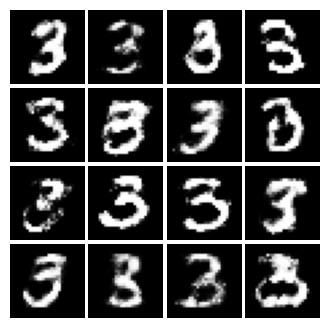

In [ ]:
generate_digit_samples(G, digit=3, n_samples=16)

Save the model

In [ ]:
torch.save(G.state_dict(), "cgan_G.pth")
torch.save(D.state_dict(), "cgan_D.pth")

What changed from Task 1

The only key differences are:

Generator now uses noise + label
Discriminator now uses image + label
labels are converted to one-hot vectors
generation is now controlled by the chosen class

## **Task 4**

Define and Train a Baseline CNN on MNIST

In [ ]:
# Task 4: Train a CNN MNIST model
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Define a simple CNN
class MNIST_CNN(nn.Module):
    def __init__(self):
        super(MNIST_CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model = MNIST_CNN().to(device)
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

# Load data (reshaping back to 28x28 for CNN)
transform_cnn = transforms.Compose([transforms.ToTensor()])
train_dataset_cnn = datasets.MNIST(root='./MNIST', train=True, transform=transform_cnn, download=True)
train_loader_cnn = DataLoader(train_dataset_cnn, batch_size=64, shuffle=True)
test_dataset_cnn = datasets.MNIST(root='./MNIST', train=False, transform=transform_cnn, download=True)

# Train the CNN for 3 epochs
cnn_model.train()
for epoch in range(3):
    for data, target in train_loader_cnn:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = cnn_model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()
print("CNN Training Complete!")

CNN Training Complete!


Targeted Adversarial Attack (Classify 4 as 9)

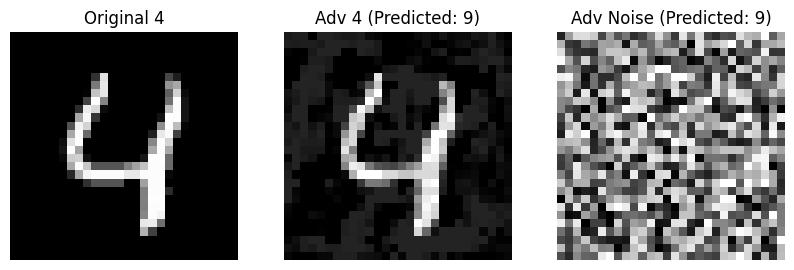

In [ ]:
# Task 4: Targeted Adversarial Attack (Iterative FGSM)
def targeted_attack(image, target_class, model, steps=100, alpha=0.01):
    image = image.clone().detach().to(device)
    image.requires_grad = True
    target = torch.tensor([target_class]).to(device)

    for step in range(steps):
        output = model(image)
        pred = output.max(1, keepdim=True)[1].item()
        if pred == target_class:
            break # Attack succeeded

        model.zero_grad()
        # For targeted attack, we MINIMIZE the loss towards the target class
        loss = F.nll_loss(output, target)
        loss.backward()

        # Adjust image towards the target class gradient
        with torch.no_grad():
            image = image - alpha * image.grad.sign()
            image = torch.clamp(image, 0, 1) # Keep image in valid pixel range
        image.requires_grad = True

    return image, pred

# 1. Attack a '4' to make it a '9'
cnn_model.eval()
image_4 = None
for data, target in test_dataset_cnn:
    if target == 4:
        image_4 = data.unsqueeze(0)
        break

adv_image_4, final_pred_4 = targeted_attack(image_4, target_class=9, model=cnn_model)

# 2. Attack a random noise image to make it a '9'
noise_image = torch.rand((1, 1, 28, 28))
adv_noise, final_pred_noise = targeted_attack(noise_image, target_class=9, model=cnn_model, steps=200)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes[0].imshow(image_4.squeeze().cpu().numpy(), cmap='gray')
axes[0].set_title("Original 4")
axes[1].imshow(adv_image_4.detach().squeeze().cpu().numpy(), cmap='gray')
axes[1].set_title(f"Adv 4 (Predicted: {final_pred_4})")
axes[2].imshow(adv_noise.detach().squeeze().cpu().numpy(), cmap='gray')
axes[2].set_title(f"Adv Noise (Predicted: {final_pred_noise})")
for ax in axes: ax.axis('off')
plt.show()

### Task 4 Observation & Reasoning
**How are adversarial images produced?** Adversarial images are created by calculating the gradient of the loss function with respect to the input pixels, rather than the model weights. By slightly adjusting the pixels in the direction that minimizes the loss for a false target class (e.g., '9'), the model is mathematically tricked into predicting the wrong class with high confidence, even though the human eye still sees a '4'.

**Comparing '4' vs 'Random Noise':**
When attacking the '4', the attack only needed to make imperceptible pixel tweaks because a '4' and '9' already share similar structural features (a loop and a stem). When attacking the random noise, the algorithm mathematically adjusted the noise to activate the model's '9' feature maps. To the human eye, it remains meaningless static, but to the CNN, the precise arrangement of noise perfectly triggers the mathematical weights associated with a '9'. This highlights that CNNs learn abstract feature representations, not human-like visual understanding.

## **Task 5**

Simple UNet Architecture for Diffusion

In [ ]:
# Task 5: Diffusion Model (Simple UNet)
class SimpleUNet(nn.Module):
    def __init__(self):
        super(SimpleUNet, self).__init__()
        self.down1 = nn.Sequential(nn.Conv2d(1, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.down2 = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))

        self.time_embed = nn.Linear(1, 128) # Simple time embedding

        self.up1 = nn.Sequential(nn.ConvTranspose2d(128, 64, 2, stride=2), nn.ReLU())
        self.up2 = nn.Sequential(nn.ConvTranspose2d(64, 1, 2, stride=2))

    def forward(self, x, t):
        t_emb = F.relu(self.time_embed(t.float().unsqueeze(1)))
        t_emb = t_emb.view(-1, 128, 1, 1)

        d1 = self.down1(x)
        d2 = self.down2(d1)

        d2 = d2 + t_emb # Inject time information

        u1 = self.up1(d2)
        u2 = self.up2(u1 + d1) # Skip connection
        return u2

diff_model = SimpleUNet().to(device)
diff_optimizer = optim.Adam(diff_model.parameters(), lr=1e-3)

**Train the Diffusion Model**

In [ ]:
# Task 5: Training DDPM on MNIST
num_steps = 100
beta = torch.linspace(0.0001, 0.02, num_steps).to(device)
alpha = 1.0 - beta
alpha_bar = torch.cumprod(alpha, dim=0)

diff_model.train()
epochs = 5
for epoch in range(epochs):
    total_loss = 0
    for data, _ in train_loader_cnn:
        data = data.to(device)
        batch_size = data.size(0)

        # Sample random time steps
        t = torch.randint(0, num_steps, (batch_size,), device=device)

        # Generate Gaussian noise
        noise = torch.randn_like(data)

        # Forward diffusion process (add noise to image)
        a_bar_t = alpha_bar[t].view(-1, 1, 1, 1)
        noisy_image = torch.sqrt(a_bar_t) * data + torch.sqrt(1 - a_bar_t) * noise

        # Predict the noise using the UNet
        predicted_noise = diff_model(noisy_image, t)

        loss = F.mse_loss(predicted_noise, noise)

        diff_optimizer.zero_grad()
        loss.backward()
        diff_optimizer.step()
        total_loss += loss.item()

    print(f"Diffusion Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader_cnn):.4f}")

Diffusion Epoch 1/5 | Loss: 1.4748
Diffusion Epoch 2/5 | Loss: 0.6506
Diffusion Epoch 3/5 | Loss: 0.6183
Diffusion Epoch 4/5 | Loss: 0.5732
Diffusion Epoch 5/5 | Loss: 0.5717


**Sample and Visualize from Diffusion**

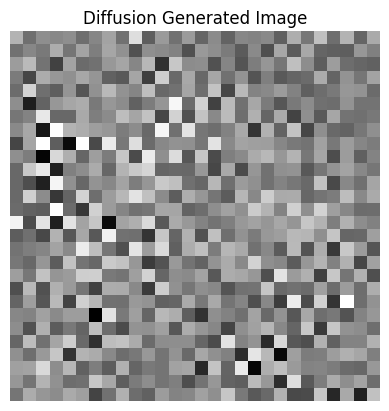

In [ ]:
# Task 5: Sampling from the Diffusion Model
diff_model.eval()
with torch.no_grad():
    # Start with pure noise
    sample = torch.randn((1, 1, 28, 28)).to(device)

    # Reverse diffusion process (denoising step by step)
    for i in reversed(range(num_steps)):
        t = torch.tensor([i], device=device)
        predicted_noise = diff_model(sample, t)

        alpha_t = alpha[t].view(-1, 1, 1, 1)
        alpha_bar_t = alpha_bar[t].view(-1, 1, 1, 1)
        beta_t = beta[t].view(-1, 1, 1, 1)

        # Remove the predicted noise
        if i > 0:
            noise = torch.randn_like(sample)
        else:
            noise = torch.zeros_like(sample)

        sample = (1 / torch.sqrt(alpha_t)) * (sample - ((1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)) * predicted_noise) + torch.sqrt(beta_t) * noise

plt.imshow(sample.detach().cpu().squeeze(), cmap='gray')
plt.title("Diffusion Generated Image")
plt.axis('off')
plt.show()

### Task 5: Diffusion vs GANs
**How the Diffusion Model Works:**
A diffusion model works in two phases. The *Forward Process* gradually adds Gaussian noise to an image over multiple timesteps until it becomes pure static. The *Reverse Process* trains a neural network (typically a U-Net) to predict and subtract that noise step-by-step. By starting with pure random noise and running it through the trained reverse process, the model gradually "denoises" the static into a coherent image (like an MNIST digit).

**Difference between GAN and Stable Diffusion:**
1. **Architecture:** A GAN (Task 3) consists of two competing networks (Generator and Discriminator) battling in a zero-sum game. A Diffusion model consists of a single network trying to minimize the mean squared error of noise prediction.
2. **Generation Process:** GANs generate an image in a single forward pass, making them very fast. Diffusion models require multiple iterative steps (e.g., 100 to 1000 steps) to gradually denoise an image, making generation much slower but often resulting in higher quality and diversity.
3. **Training Stability:** As seen in Task 1, GANs suffer from mode collapse and volatile loss functions. Diffusion models are trained using simple Mean Squared Error (MSE) to predict noise, making their training mathematically highly stable and reliable.